Здесь я занимаюсь тестированием и обучением моделей для третьего этапа.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
import importlib
import os
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import clear_output
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

# Форсируем приватный импорт для избежания багов окружения colab/jupyter
try:
    import torch._utils
except AttributeError:
    if 'torch._utils' not in sys.modules:
        sys.modules['torch._utils'] = importlib.import_module('torch._utils')

# CE Loss

## Загрузка данных

Для начала т.к. постановка задачи через CE loss это просто классификация, нам нужны классы. Их можно узнать сопоставив имена с изображениями. Этим мы сейчас и займемся с помощью identity_CelebA.txt

In [ ]:


BASE_DIR = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1'
TRAIN_ZIP = os.path.join(BASE_DIR, 'Dataset/aligned_train.zip')
TEST_ZIP = os.path.join(BASE_DIR, 'Dataset/aligned_test.zip')

# Путь к оригинальной разметке личностей CelebA
IDENTITY_TXT_PATH = os.path.join(BASE_DIR, 'CelebA/Anno/identity_CelebA.txt')

# Папки для распаковки на быстрый диск Colab
EXTRACT_TRAIN_DIR = '/content/aligned_train'
EXTRACT_TEST_DIR = '/content/aligned_test'

In [ ]:
# Распаковка обучающей выборки
if not os.path.exists(EXTRACT_TRAIN_DIR):
    print("Распаковка обучающего датасета...")
    with zipfile.ZipFile(TRAIN_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_TRAIN_DIR)
    print("Распаковка Train завершена.")

# Распаковка тестовой выборки
if not os.path.exists(EXTRACT_TEST_DIR):
    print("Распаковка валидационного датасета...")
    with zipfile.ZipFile(TEST_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_TEST_DIR)
    print("Распаковка Test завершена.")

train_images = set(os.listdir(EXTRACT_TRAIN_DIR))
test_images = set(os.listdir(EXTRACT_TEST_DIR))

print(f"Найдено изображений в Train: {len(train_images)}")
print(f"Найдено изображений в Test: {len(test_images)}")


Распаковка обучающего датасета...
Распаковка Train завершена.
Распаковка валидационного датасета...
Распаковка Test завершена.
Найдено изображений в Train: 10425
Найдено изображений в Test: 2664


In [ ]:
# Загрузка оригинальной разметки личностей
df_identity = pd.read_csv(IDENTITY_TXT_PATH, sep=r'\s+', header=None, names=['image_name', 'person_id'])
df_filtered = df_identity[df_identity['image_name'].isin(train_images | test_images)].copy()
df_filtered['is_test'] = df_filtered['image_name'].isin(test_images).astype(int)

# Важно: кодируем person_id в последовательные индексы классов [0, NUM_CLASSES-1]
# Делаем это ДО разделения, чтобы маппинг ID человека -> класс был строго одинаковым везде!
df_filtered['label'] = df_filtered['person_id'].astype('category').cat.codes

# Разделяем обратно на train и val DataFrame
df_train = df_filtered[df_filtered['is_test'] == 0].copy().reset_index(drop=True)
df_test = df_filtered[df_filtered['is_test'] == 1].copy().reset_index(drop=True)

NUM_CLASSES = df_filtered['label'].nunique()

print(f"\n--- Итоговая статистика нового датасета ---")
print(f"Количество уникальных людей (классов): {NUM_CLASSES}")
print(f"Строк в df_train: {len(df_train)}")
print(f"Строк in df_test: {len(df_test)}")
print("\nРаспределение количества фото на человека в Train:")
print(df_train['label'].value_counts().describe())
print("\nРаспределение количества фото на человека в Test:")
print(df_test['label'].value_counts().describe())


--- Итоговая статистика нового датасета ---
Количество уникальных людей (классов): 700
Строк в df_train: 10425
Строк in df_test: 2664

Распределение количества фото на человека в Train:
count    700.000000
mean      14.892857
std        0.892637
min       14.000000
25%       14.000000
50%       15.000000
75%       16.000000
max       16.000000
Name: count, dtype: float64

Распределение количества фото на человека в Test:
count    700.000000
mean       3.805714
std        0.395933
min        3.000000
25%        4.000000
50%        4.000000
75%        4.000000
max        4.000000
Name: count, dtype: float64


Вот так как то. Получается всреднем на каждого человека вышло около 15 фото в трейне и 4 в тесте. Неплохо. На этом вполне можно обучаться.

На всякий сохраним еще раз, с пометкой что ушло в тест а что в трейн. (Сохраняется csv файл, так как изображений не менялись)

In [ ]:
import os
import pandas as pd

df_train['split'] = 'train'
df_test['split'] = 'test'

df_splits = pd.concat([df_train, df_test], ignore_index=True)
SAVE_PATH = os.path.join(BASE_DIR, 'Dataset/split_info.csv')
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
df_splits.to_csv(SAVE_PATH, index=False)

print(f"Информация о разбиении сохранена в: {SAVE_PATH}")
print(f"Итого строк в файле split_info: {len(df_splits)}")
print(df_splits['split'].value_counts())

Информация о разбиении сохранена в: /content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/split_info.csv
Итого строк в файле split_info: 13089
split
train    10425
test      2664
Name: count, dtype: int64


## Пайплайн данных

Сейчас для удобства я соберу класс для данных. Центральный кроп - что бы не менять стандартизацию лиц. Переводим из 256-256 в 224-224. - Изначально это было для ResNet c входом 224*224, а потом я уж решил не менять. Как раз обрезаем лишний фон.

In [ ]:
shared_transforms = T.Compose([
    T.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CelebAClassificationDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        """
        df: DataFrame со сплитом (содержит колонки 'image_name' и 'label')
        img_dir: Путь к конкретной распакованной папке с картинками (train или test)
        transform: Пайплайн трансформаций
        """
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_name'])

        # Открываем изображение и конвертируем в RGB
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
BATCH_SIZE = 128

# Инициализируем датасеты, передавая правильные папки для каждого сплита
train_dataset = CelebAClassificationDataset(
    df=df_train,
    img_dir=EXTRACT_TRAIN_DIR,
    transform=shared_transforms
)

test_dataset = CelebAClassificationDataset(
    df=df_test,
    img_dir=EXTRACT_TEST_DIR,
    transform=shared_transforms
)

# Создаем DataLoader`ы
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Батчей в train_loader: {len(train_loader)}")
print(f"Батчей в test_loader: {len(test_loader)}")

Батчей в train_loader: 81
Батчей в test_loader: 21


## Архитектура и обучение

Внизу я распишу ход своих эксперементов. Факт что финальная модель - маленткая понижайка размерности на 1КК параметров. Не смог взять предобученную из за логики датасета. Классов 700, картинок +-15 на человека. Получается очень сильный оверфит на первых же эпохах.

Про саму архитектуру могу сказать что идёт скелет как у условного AlexNet. Четыре блока с конвами и нормализацией, а после них дропауты(даже модель с 1КК параметров переобучалась, пришлось ограничивать ее). После bottlecheck слой эмбейдингов.

Как итог обучалось это чудо 3 часа. Первые 40 эпох оно учило геометрию мира, а потом пошли черты лица. Вот когда это началось, пошло расхождение графиков, но я думаю прям полностью переобучения тут не избежать. Все же это байзлайн и вообще CE loss не особо предназначен для такого числа классов.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class FaceReductionNet(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super(FaceReductionNet, self).__init__()

        # Блок 1: Вход 224x224 -> Выход 112x112
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.Mish(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.1)
        )

        # Блок 2: Вход 112x112 -> Выход 56x56
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.Mish(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2)
        )

        # Блок 3: Вход 56x56 -> Выход 28x28
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.Mish(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3)
        )

        # Блок 4: Вход 28x28 -> Выход 14x14
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.4)
        )

        # Глобальное сжатие: 14x14 -> 1x1
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Голова (Эмбеддинг): 256 -> 512 измерений
        self.embedding_layer = nn.Sequential(
            nn.Linear(256, embedding_dim),
            nn.BatchNorm1d(embedding_dim) # Без активации на выходе
        )

        # Классификатор на 700 классов под обычный CrossEntropyLoss
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embeddings=False):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1) # Превращаем в вектор размера 256

        embeddings = self.embedding_layer(x)

        if return_embeddings:
            return embeddings

        logits = self.classifier(embeddings)
        return logits


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FaceReductionNet(num_classes=NUM_CLASSES, embedding_dim=512).to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=3e-2)

NUM_EPOCHS = 200
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

history = {
    'train_loss': [], 'test_loss': [],
    'train_acc': [], 'test_acc': []
}
best_test_acc = 0.0

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Наша кастомная сеть создана! Всего обучаемых параметров: {total_params / 1e6:.3f} млн.")


Наша кастомная сеть создана! Всего обучаемых параметров: 1.075 млн.


К коду обучения у меня (помимо обучения) были требования вывода графиков в режиме реального времени.

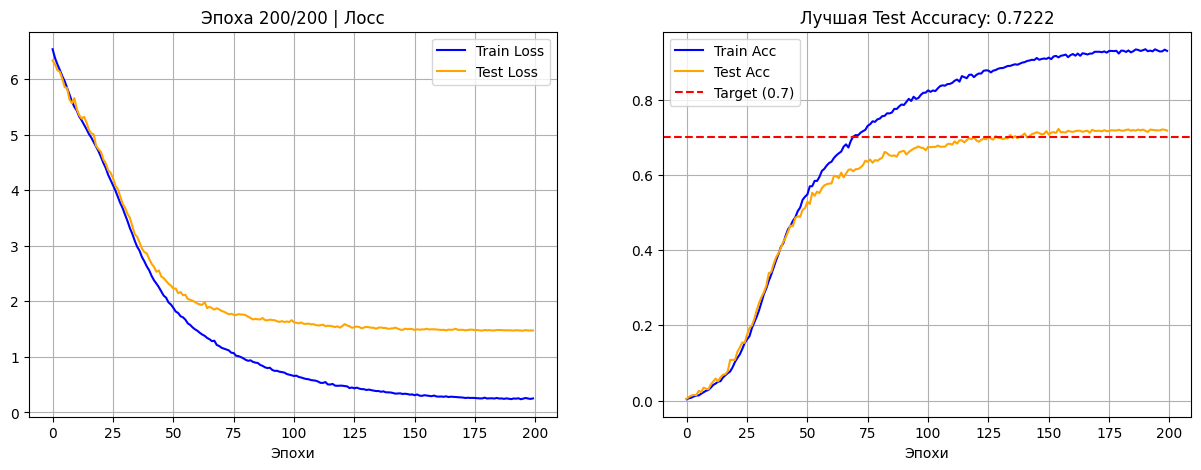

Обучение на завершено! Лучшая точность на тесте: 0.7222


In [ ]:
print("Начинаем процесс обучения...")

for epoch in range(NUM_EPOCHS):

    # --- ЭПОХА ОБУЧЕНИЯ (TRAIN) ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(logits, 1)
        train_correct += torch.sum(preds == labels.data)
        train_total += images.size(0)

    train_loss = train_loss / train_total
    train_acc = (train_correct.double() / train_total).item()

    # --- ЭПОХА ТЕСТИРОВАНИЯ (TEST) ---
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(logits, 1)
            test_correct += torch.sum(preds == labels.data)
            test_total += images.size(0)

    test_loss = test_loss / test_total
    test_acc = (test_correct.double() / test_total).item()

    scheduler.step()

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model.state_dict(), os.path.join(BASE_DIR, 'weights/baseline_ce_model.pth'))

    # --- ОБНОВЛЕНИЕ ГРАФИКОВ ---
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['test_loss'], label='Test Loss', color='orange')
    ax1.set_title(f'Эпоха {epoch+1}/{NUM_EPOCHS} | Лосс')
    ax1.set_xlabel('Эпохи')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history['train_acc'], label='Train Acc', color='blue')
    ax2.plot(history['test_acc'], label='Test Acc', color='orange')
    ax2.axhline(y=0.7, color='red', linestyle='--', label='Target (0.7)')
    ax2.set_title(f'Лучшая Test Accuracy: {best_test_acc:.4f}')
    ax2.set_xlabel('Эпохи')
    ax2.legend()
    ax2.grid(True)

    plt.show()

torch.save(model.state_dict(), os.path.join(BASE_DIR, 'weights/baseline_ce_model_2.pth'))

print(f"Обучение на завершено! Лучшая точность на тесте: {best_test_acc:.4f}")

In [ ]:
torch.save(model.state_dict(), os.path.join(BASE_DIR, 'weights/baseline_ce_model_3.pth'))

Итак, история моего успеха:

-Начал я с датасета на 10К изображений(всего) как итог учились мы на 8К. Самое интересное - уникальных людей было 5К Как итог +- 2 фото на человека и не возможность обучится. Как архитектура был ResNet34 и голова, архитектуру головы уже не помню, н помню что там были ReLu. Я немного попытался потюнить параметры, но ничего, естественно, не решилось. acc +- 0.05

-Я спросил у автора про датасет и пределал его. Теперь он такой как есть 700/19 из которых 15 в трейне а 4 в тесте. Архитектура та же, но мы переобучались на второй эпохе (у ResNet 25КК параметров). Она тупо все запоминала. acc +- 0.2/0.3

-Я спросил в чате и мне подсказали на счёт EfficientNet(5КК параметров). Она переобучалась к 5/7 эпохе. Я пытался чинить это заморозкой-разморозкой тела, архитектурой головы(я тогда нашел в статье какой то как делали голову для подобной сетки и отказался от ReLu и Dropaut, думал поможет), но как итог максимум - асс - 0,5 стабильно.

-Ну раз 5КК много напишем свою сетку на пару лямов параметров. После многочасовых эксперементов(Я думал с ума сойду) пришел к архитектуре стандартной сверточной сети с головой из пары слоёв линейных эмбейдингов. Подтюнив параметры и закрутив гайки dropout'а я пробил заветные 0,7. Меня все устраивает, кроме времени которое я потратил. Хотя опят был полезный. Я узнал как сильно корелирют качество - рамер датасета - глубина модели.

# ArcFace Loss

Как я понял это не совсем лосс в привычном понимании. Скорее еще один кусочек конструктора нейросетей. Код дата пайплайна и большая часть цикла обучения просто скопированы.

## Дата пайплайн

In [ ]:
shared_transforms = T.Compose([
    T.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class CelebAClassificationDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        """
        df: DataFrame со сплитом (содержит колонки 'image_name' и 'label')
        img_dir: Путь к конкретной распакованной папке с картинками (train или test)
        transform: Пайплайн трансформаций
        """
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image_name'])

        # Открываем изображение и конвертируем в RGB
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label

BATCH_SIZE = 128

# Инициализируем датасеты, передавая правильные папки для каждого сплита
train_dataset = CelebAClassificationDataset(
    df=df_train,
    img_dir=EXTRACT_TRAIN_DIR,
    transform=shared_transforms
)

test_dataset = CelebAClassificationDataset(
    df=df_test,
    img_dir=EXTRACT_TEST_DIR,
    transform=shared_transforms
)

# Создаем DataLoader`ы
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Батчей в train_loader: {len(train_loader)}")
print(f"Батчей в test_loader: {len(test_loader)}")


Батчей в train_loader: 81
Батчей в test_loader: 21


## Архитектура и обучение

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

Этот класс реализует ArcFace. В задании четко не написано писать ее самим или брать из библиотек, но "китайские друзья" сказакли, что в какой то библиотеке есть, но она там с оптимизацией под огромные датасеты, то се и вообще мы ее сами напишем.

In [ ]:
class ArcMarginProduct_Safe(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.30):
        super(ArcMarginProduct_Safe, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)

        # Предохранитель: пороговый угол, чтобы не уйти за pre-boundary
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label=None):
        # 1. Нормализация векторов
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        # Стабилизация для float16 / подстраховка от nan
        cosine = cosine.clamp(-1.0 + 1e-7, 1.0 - 1e-7)

        if label is None:
            return cosine * self.s

        # 2. Считаем синус
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))

        # 3. Эффект угла cos(theta + m)
        phi = cosine * self.cos_m - sine * self.sin_m

        # Безопасное переключение (Easy Margin): если угол тупой, не ломаем градиент
        phi = torch.where(cosine > 0, phi, cosine)

        # 4. Маскирование целевого класса
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)

        # 5. Сборка логитов
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output *= self.s

        return output

Бэкбон взял от прошлой сетки, пока. ПОтом глянем, может и поменяю. Ну а если работает, зачем это что то чинить)))

In [ ]:
class FaceReductionNet(nn.Module):
    def __init__(self, num_classes=700, embedding_dim=512):
        super(FaceReductionNet, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.Mish(),
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.05) # Было 0.1 -> сделали 0.05
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.Mish(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.1) # Было 0.2 -> сделали 0.1
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.Mish(),
            nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.2) # Было 0.3 -> сделали 0.2
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256), nn.Mish(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(0.3) # Было 0.4 -> сделали 0.3
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.embedding_layer = nn.Sequential(
            nn.Linear(256, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embeddings=False):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        embeddings = self.embedding_layer(x)

        if return_embeddings:
            return embeddings
        return self.classifier(embeddings)

In [ ]:
NUM_CLASSES = 700
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FaceReductionNet(num_classes=NUM_CLASSES, embedding_dim=512).to(device)
metric_fc = ArcMarginProduct_Safe(in_features=512, out_features=NUM_CLASSES, s=64.0, m=0.15).to(device)

baseline_path = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/weights/baseline_ce_model.pth'

print("🔥 Обнаружен базовый чекпоинт. Загружаем веса...")
checkpoint = torch.load(baseline_path, map_location=device)
model.load_state_dict(checkpoint, strict=True)
with torch.no_grad():
    metric_fc.weight.copy_(model.classifier.weight)
print("✅ Веса успешно восстановлены!")

for param in model.parameters():
    param.requires_grad = False
print("\n❄️ Бэкбон ЗАМОРОЖЕН.")

# Проверим, что обучается только ArcFace
trainable_model_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
trainable_head_params = sum(p.numel() for p in metric_fc.parameters() if p.requires_grad)
print(f"Обучаемых параметров в бэкбоне: {trainable_model_params}")
print(f"Обучаемых параметров в ArcFace голове: {trainable_head_params} (должно быть 358 400)")

🔥 Обнаружен базовый чекпоинт. Загружаем веса...
✅ Веса успешно восстановлены!

❄️ Бэкбон ЗАМОРОЖЕН.
Обучаемых параметров в бэкбоне: 0
Обучаемых параметров в ArcFace голове: 358400 (должно быть 358 400)


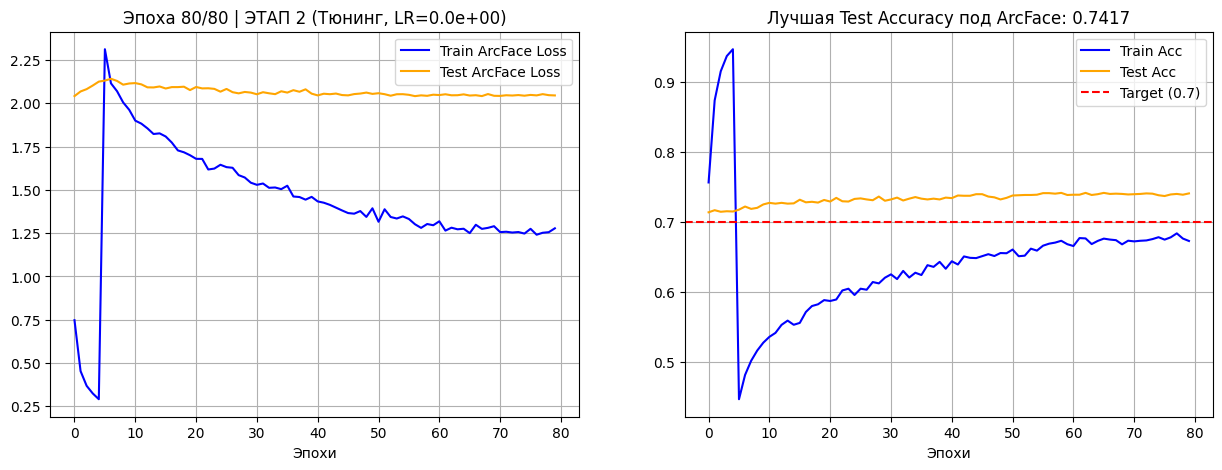

🎉 Обучение завершено! Лучшая точность на ArcFace: 0.7417


In [ ]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt

NUM_EPOCHS = 80
STAGE_1_EPOCHS = 5

criterion = nn.CrossEntropyLoss()

# На ЭТАПЕ 1 обучаем ТОЛЬКО ArcFace голову
optimizer = optim.AdamW(metric_fc.parameters(), lr=1e-3, weight_decay=1e-2)

# Статистика
history = {
    'train_loss': [], 'test_loss': [],
    'train_acc': [], 'test_acc': []
}
best_test_acc = 0.0

# Переменная-флаг, чтобы знать, что мы уже разморозились
is_unfrozen = False

print(f"🚀 Старт ЭТАПА 1: Калибровка ArcFace головы ({STAGE_1_EPOCHS} эпох)...")

for epoch in range(NUM_EPOCHS):
    epoch_idx = epoch + 1

    # --- ДИНАМИЧЕСКОЕ ПЕРЕКЛЮЧЕНИЕ ЭТАПОВ (ХАК №2) ---
    if epoch_idx > STAGE_1_EPOCHS and not is_unfrozen:
        print("\n🔥 ЭТАП 2: Размораживаем бэкбон и переходим к ускоренному тюнингу!")

        for param in model.parameters():
            param.requires_grad = True

        # Подкрутили LR: сделали чуть агрессивнее, чтобы синяя линия росла бодрее
        optimizer = optim.AdamW([
            {'params': model.parameters(), 'lr': 1e-4, 'weight_decay': 3e-2}, # Было 3e-5
            {'params': metric_fc.parameters(), 'lr': 3e-4, 'weight_decay': 1e-2} # Было 1e-4
        ])

        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS - STAGE_1_EPOCHS)
        is_unfrozen = True

    # --- ЭПОХА ОБУЧЕНИЯ (TRAIN) ---
    # Бэкбон держим в eval(), если он заморожен, чтобы BatchNorm не плыл от новых батчей.
    # Если разморожен — включаем полноценный train().
    if not is_unfrozen:
        model.eval()
    else:
        model.train()

    metric_fc.train()

    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        # ХИРУРГИЧЕСКИЙ ВЫЗОВ: Забираем чистые эмбеддинги 512
        embeddings = model(images, return_embeddings=True)

        # Передаем в безопасный ArcFace вместе с метками
        logits = metric_fc(embeddings, labels)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(logits, 1)
        train_correct += torch.sum(preds == labels.data)
        train_total += images.size(0)

    train_loss = train_loss / train_total
    train_acc = (train_correct.double() / train_total).item()

    # --- ЭПОХА ТЕСТИРОВАНИЯ (TEST) ---
    model.eval()
    metric_fc.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # На тесте тоже забираем чистые эмбеддинги
            embeddings = model(images, return_embeddings=True)

            # label=None отключает маржин (чистая геометрия сферы)
            logits = metric_fc(embeddings, label=None)
            loss = criterion(logits, labels)

            test_loss += loss.item() * images.size(0)
            _, preds = torch.max(logits, 1)
            test_correct += torch.sum(preds == labels.data)
            test_total += images.size(0)

    test_loss = test_loss / test_total
    test_acc = (test_correct.double() / test_total).item()

    # Шагаем планировщиком только на 2-м этапе
    if is_unfrozen:
        scheduler.step()

    # Сохраняем метрики
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)

    # Сохраняем ЛУЧШИЕ веса в ОТДЕЛЬНЫЙ файл (Бейслайн не трогаем!)
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        save_dir = os.path.dirname(baseline_path)
        torch.save({
            'model_state_dict': model.state_dict(),
            'metric_fc_state_dict': metric_fc.state_dict(),
            'epoch': epoch_idx,
            'best_acc': best_test_acc
        }, os.path.join(save_dir, 'arcface_warm_start_best.pth'))

    # --- ЖИВАЯ ОТРИСОВКА ГРАФИКОВ ---
    clear_output(wait=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Статус текущего этапа для заголовка
    stage_text = f"ЭТАП 1 (Заморозка)" if not is_unfrozen else f"ЭТАП 2 (Тюнинг, LR={optimizer.param_groups[0]['lr']:.1e})"

    # График Лосса
    ax1.plot(history['train_loss'], label='Train ArcFace Loss', color='blue')
    ax1.plot(history['test_loss'], label='Test ArcFace Loss', color='orange')
    ax1.set_title(f'Эпоха {epoch_idx}/{NUM_EPOCHS} | {stage_text}')
    ax1.set_xlabel('Эпохи')
    ax1.legend()
    ax1.grid(True)

    # График Точности
    ax2.plot(history['train_acc'], label='Train Acc', color='blue')
    ax2.plot(history['test_acc'], label='Test Acc', color='orange')
    ax2.axhline(y=0.7, color='red', linestyle='--', label='Target (0.7)')
    ax2.set_title(f'Лучшая Test Accuracy под ArcFace: {best_test_acc:.4f}')
    ax2.set_xlabel('Эпохи')
    ax2.legend()
    ax2.grid(True)

    plt.show()

print(f"🎉 Обучение завершено! Лучшая точность на ArcFace: {best_test_acc:.4f}")

# Мини тестирование

Основное тестирование будет позже, в сборке финального пайплайна. Сейчас мы проверим просто что модель работает

Тут простенький код который выведет для человека не похожих людей и еще одну фотку детектированую как его же.

📊 ГЕОМЕТРИЧЕСКИЙ АНАЛИЗ СФЕРЫ ДЛЯ КЛАССА 0:
🟢 Свой человек (Positive):  Косинус = 0.2264 | Угол между лицами = 76.92°
🔴 Чужой №1 (Negative 1):    Косинус = 0.1459 | Угол между лицами = 81.61°
🔴 Чужой №2 (Negative 2):    Косинус = 0.0734 | Угол между лицами = 85.79°
✅ Успех! ArcFace стянул эмбеддинги одного человека ближе, чем эмбеддинги чужаков.


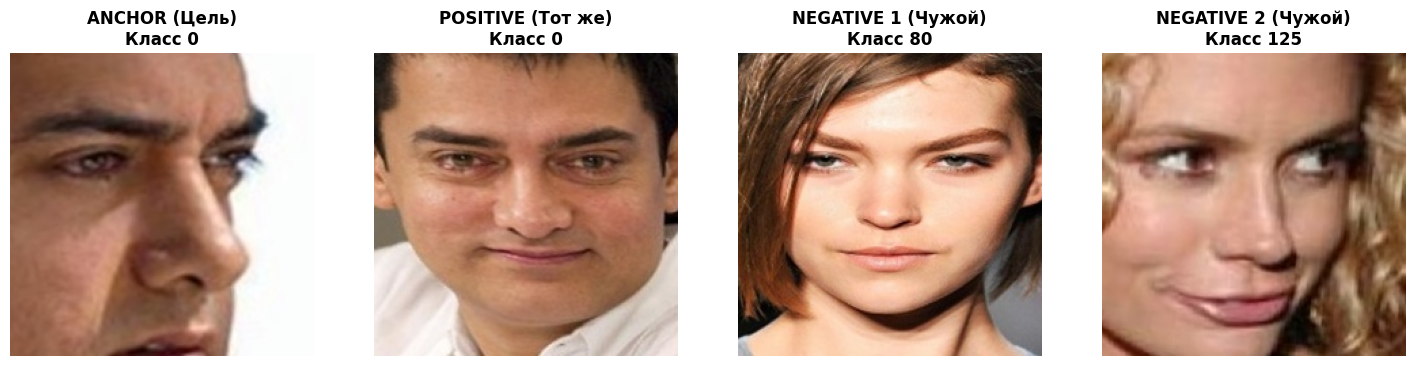

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

def run_visual_triplet_test(model, test_dataset, device):
    model.eval()

    from collections import defaultdict
    class_to_indices = defaultdict(list)
    for idx in range(len(test_dataset)):
        label = int(test_dataset.df.iloc[idx]['label'])
        class_to_indices[label].append(idx)

    valid_classes = [cls for cls, idxs in class_to_indices.items() if len(idxs) >= 2]

    if not valid_classes:
        print("⚠ В тестовом датасете не найдено классов, у которых есть >= 2 фото.")
        print("Берем просто случайные лица из датасета для сравнения.")
        return

    target_class = random.choice(valid_classes)
    target_indices = class_to_indices[target_class]

    anchor_idx, positive_idx = random.sample(target_indices, 2)

    other_classes = [cls for cls in class_to_indices.keys() if cls != target_class]
    neg1_class, neg2_class = random.sample(other_classes, 2)

    neg1_idx = random.choice(class_to_indices[neg1_class])
    neg2_idx = random.choice(class_to_indices[neg2_class])

    indices = [anchor_idx, positive_idx, neg1_idx, neg2_idx]
    images = []
    labels = []
    raw_images = []

    for idx in indices:
        img_tensor, label = test_dataset[idx]
        images.append(img_tensor)
        labels.append(label)

        img_np = img_tensor.permute(1, 2, 0).cpu().numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        raw_images.append(img_np)

    batch_images = torch.stack(images).to(device)

    with torch.no_grad():
        embeddings = model(batch_images, return_embeddings=True)

        embeddings_norm = F.normalize(embeddings, p=2, dim=1)

    emb_anchor = embeddings_norm[0]
    emb_positive = embeddings_norm[1]
    emb_neg1 = embeddings_norm[2]
    emb_neg2 = embeddings_norm[3]

    sim_positive = torch.dot(emb_anchor, emb_positive).item()
    sim_neg1 = torch.dot(emb_anchor, emb_neg1).item()
    sim_neg2 = torch.dot(emb_anchor, emb_neg2).item()

    angle_positive = np.degrees(np.arccos(np.clip(sim_positive, -1.0, 1.0)))
    angle_neg1 = np.degrees(np.arccos(np.clip(sim_neg1, -1.0, 1.0)))
    angle_neg2 = np.degrees(np.arccos(np.clip(sim_neg2, -1.0, 1.0)))

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    titles = [
        f"ANCHOR (Цель)\nКласс {labels[0]}",
        f"POSITIVE (Тот же)\nКласс {labels[1]}",
        f"NEGATIVE 1 (Чужой)\nКласс {labels[2]}",
        f"NEGATIVE 2 (Чужой)\nКласс {labels[3]}"
    ]

    for i, ax in enumerate(axes):
        ax.imshow(raw_images[i])
        ax.set_title(titles[i], fontsize=12, fontweight='bold')
        ax.axis('off')

    # Выводим геометрию сферы под графиками
    print("="*65)
    print(f"📊 ГЕОМЕТРИЧЕСКИЙ АНАЛИЗ СФЕРЫ ДЛЯ КЛАССА {labels[0]}:")
    print("="*65)
    print(f"🟢 Свой человек (Positive):  Косинус = {sim_positive:.4f} | Угол между лицами = {angle_positive:.2f}°")
    print(f"🔴 Чужой №1 (Negative 1):    Косинус = {sim_neg1:.4f} | Угол между лицами = {angle_neg1:.2f}°")
    print(f"🔴 Чужой №2 (Negative 2):    Косинус = {sim_neg2:.4f} | Угол между лицами = {angle_neg2:.2f}°")
    print("="*65)

    if sim_positive > sim_neg1 and sim_positive > sim_neg2:
        print("✅ Успех! ArcFace стянул эмбеддинги одного человека ближе, чем эмбеддинги чужаков.")
    else:
        print("❌ Аномалия: Чужое лицо оказалось ближе, чем альтернативное фото цели.")

run_visual_triplet_test(model, test_dataset, device)


А теперь запуск той же функции

In [ ]:
import os
import shutil
import zipfile

zip_path = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/Dataset/aligned_val.zip'
extract_path = '/content/aligned_val_extracted'

if os.path.exists(extract_path):
    print("🧹 Обнаружена старая папка. Очистка перед перезаписью...")
    shutil.rmtree(extract_path)

print("📦 Распаковка валидационного датасета...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("✅ Распаковка завершена!")

🧹 Обнаружена старая папка. Очистка перед перезаписью...
📦 Распаковка валидационного датасета...
✅ Распаковка завершена!


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

class CelebA_Drive_OOD_Dataset(Dataset):
    def __init__(self, img_dir, identity_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform

        all_files = sorted(os.listdir(img_dir))
        self.valid_images = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

        self.img_to_id = {}
        if os.path.exists(identity_file):
            with open(identity_file, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 2:
                        self.img_to_id[parts[0]] = int(parts[1])
        else:
            raise FileNotFoundError(f"❌ Файл разметки не найден по пути: {identity_file}")

        self.imgs = []
        for img_name in self.valid_images:
            real_id = self.img_to_id.get(img_name, -1)
            if real_id != -1:
                full_path = os.path.join(img_dir, img_name)
                self.imgs.append((full_path, real_id))
            else:
                print(f"⚠ Предупреждение: Файл {img_name} не найден в identity_CelebA.txt")

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, idx):
        img_path, class_id = self.imgs[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, class_id

extract_path = '/content/aligned_val_extracted'
identity_drive_path = '/content/drive/MyDrive/Дз Ноутбуки DLS/Первый поток/Проект 1/CelebA/Anno/identity_CelebA.txt'

val_transforms = T.Compose([
    T.CenterCrop((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_dataset = CelebA_Drive_OOD_Dataset(
    img_dir=extract_path,
    identity_file=identity_drive_path,
    transform=val_transforms
)

print(f"✅ Локальный OOD датасет успешно собран через identity_CelebA.txt!")
print(f"Всего картинок сопоставлено: {len(val_dataset)}")
unique_ids = set([lbl for _, lbl in val_dataset.imgs])
print(f"Уникальных РЕАЛЬНЫХ людей в валидационном сете: {len(unique_ids)}")

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

✅ Локальный OOD датасет успешно собран через identity_CelebA.txt!
Всего картинок сопоставлено: 300
Уникальных РЕАЛЬНЫХ людей в валидационном сете: 50


🔮 ПРОВЕРКА ОБОБЩАЮЩЕЙ СПОСОБНОСТИ НА ЛЮДЯХ, КОТОРЫХ НЕТ В ОБУЧАЮЩЕЙ ВЫБОРКЕ:
🟢 Свой человек (Positive):  Косинус = 0.4727 | Угол между лицами = 61.79°
🔴 Чужой №1 (Negative 1):    Косинус = 0.2787 | Угол между лицами = 73.82°
🔴 Чужой №2 (Negative 2):    Косинус = -0.0874 | Угол между лицами = 95.01°
🚀 ФАНТАСТИКА! Модель идеально обобщает геометрию: незнакомые лица стягиваются правильно!


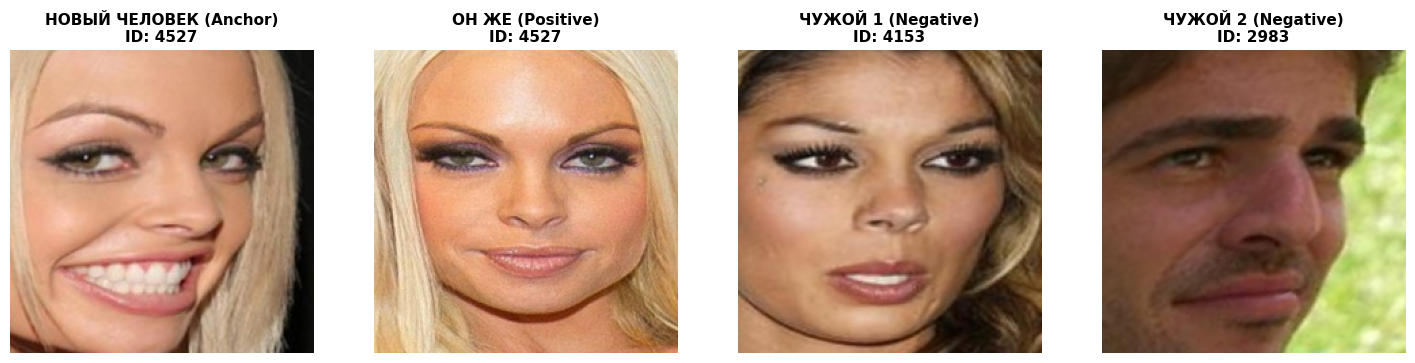

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from collections import defaultdict

def run_ood_triplet_test(model, dataset, device):
    """
    Тестирует модель на людях, которых она никогда не видела при обучении.
    Строит триплет (Anchor, Positive, Negative 1, Negative 2) и считает углы на сфере.
    """
    model.eval()

    # 1. Группируем индексы картинок по классам новых людей
    class_to_indices = defaultdict(list)
    for idx, (_, class_idx) in enumerate(dataset.imgs):
        class_to_indices[class_idx].append(idx)

    # Ищем классы, где есть >= 2 фотографии для триплета
    valid_classes = [cls for cls, idxs in class_to_indices.items() if len(idxs) >= 2]

    if not valid_classes:
        print("❌ Ошибка: В валидационном сете нет людей, у которых есть хотя бы 2 фотографии!")
        return

    # Выбираем случайного целевого человека из будущего
    target_class = random.choice(valid_classes)
    target_indices = class_to_indices[target_class]

    anchor_idx, positive_idx = random.sample(target_indices, 2)

    # Выбираем двух случайных чужих людей
    other_classes = [cls for cls in class_to_indices.keys() if cls != target_class]
    neg1_class, neg2_class = random.sample(other_classes, 2)

    neg1_idx = random.choice(class_to_indices[neg1_class])
    neg2_idx = random.choice(class_to_indices[neg2_class])

    # 2. Собираем изображения и денормализуем для отрисовки
    indices = [anchor_idx, positive_idx, neg1_idx, neg2_idx]
    images = []
    raw_images = []

    for idx in indices:
        img_tensor, _ = dataset[idx]
        images.append(img_tensor)

        # Денормализация
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img_np = np.clip(img_np, 0, 1)
        raw_images.append(img_np)

    batch_images = torch.stack(images).to(device)

    # 3. Прогоняем через модель и извлекаем ЧИСТЫЕ эмбеддинги (без головы классификатора)
    with torch.no_grad():
        embeddings = model(batch_images, return_embeddings=True)
        # Проецируем на сферу (L2-нормализация)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)

    # Считаем косинусы углов (скалярное произведение нормализованных векторов)
    sim_positive = torch.dot(embeddings_norm[0], embeddings_norm[1]).item()
    sim_neg1 = torch.dot(embeddings_norm[0], embeddings_norm[2]).item()
    sim_neg2 = torch.dot(embeddings_norm[0], embeddings_norm[3]).item()

    # Переводим в градусы
    angle_positive = np.degrees(np.arccos(np.clip(sim_positive, -1.0, 1.0)))
    angle_neg1 = np.degrees(np.arccos(np.clip(sim_neg1, -1.0, 1.0)))
    angle_neg2 = np.degrees(np.arccos(np.clip(sim_neg2, -1.0, 1.0)))

    # 4. Визуализация
    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    titles = [
        f"НОВЫЙ ЧЕЛОВЕК (Anchor)\nID: {target_class}",
        f"ОН ЖЕ (Positive)\nID: {target_class}",
        f"ЧУЖОЙ 1 (Negative)\nID: {neg1_class}",
        f"ЧУЖОЙ 2 (Negative)\nID: {neg2_class}"
    ]

    for i, ax in enumerate(axes):
        ax.imshow(raw_images[i])
        ax.set_title(titles[i], fontsize=11, fontweight='bold')
        ax.axis('off')

    print("="*75)
    print("🔮 ПРОВЕРКА ОБОБЩАЮЩЕЙ СПОСОБНОСТИ НА ЛЮДЯХ, КОТОРЫХ НЕТ В ОБУЧАЮЩЕЙ ВЫБОРКЕ:")
    print("="*75)
    print(f"🟢 Свой человек (Positive):  Косинус = {sim_positive:.4f} | Угол между лицами = {angle_positive:.2f}°")
    print(f"🔴 Чужой №1 (Negative 1):    Косинус = {sim_neg1:.4f} | Угол между лицами = {angle_neg1:.2f}°")
    print(f"🔴 Чужой №2 (Negative 2):    Косинус = {sim_neg2:.4f} | Угол между лицами = {angle_neg2:.2f}°")
    print("="*75)

    if sim_positive > sim_neg1 and sim_positive > sim_neg2:
        print("🚀 ФАНТАСТИКА! Модель идеально обобщает геометрию: незнакомые лица стягиваются правильно!")
    else:
        print("🛈 Модель испытывает трудности с разделением этих конкретных незнакомых лиц.")

run_ood_triplet_test(model, val_dataset, device)

Ураааа, я отмучался, пять дней не мог обучить модель и составить тест. Все проблемы какие то. Не вините меня за тупой нейрокод, я уже заколебался под конец и просто заливал код + ошибку в чат и вставлял обратно. Я имею в виду только функции тестирования с лицами которые.

Вот история моего успеха 2:

- То что смысла брать предобученную сетку снова нет смысла, бало ясно с начала. Она бы просто переобучилась. В связи с этим я принял решение использовать старую архитектуру и долепить уже к ней ArcFace блок.

- Не, ну я попробовал обучить сеть с нуля, но это гробовая затея. Градиенты не  текли, да и почитав статьи я понял, что так в сообществе не принято.

- Не считая точечной поткрутки маржина, learningRate и dropout в сетке я ничего не менял с первой инициализации. Я просто залил сохранённые веса с прошлой модели, отрезал классификационный блок, и между ними с бэкбоном всадил ArcFace. Обучение идёт первые 5 эпох с замароженым бэкбоном, для подтягивания центров на окружности. Далее обучение идёт для всей сетки с умеренным LR.

ПРоблемы с которыми я столкнулся:
Оказывается веса были накрен удалены и сетка ингициализировалась случайно. ПРишлось переучивать класификацию - а это 4 часа. Как итог я веса сохранил 4 раза и на каждый еще копию делал. Когда весь код был написан, но я не мог оставить модель обучиться. Так как я в деревне то у нас: то глушат - те в колаб я не зайду, то гроза и ноут брать нельзя, то связь ловить перестанет, то я уеду на рыбалку на целый день, хорошую щучку такую выловил кстати.
Вобщем не считая этого и пары глупых эксперементов в начале, пока я изучал литературу - все прошло кладенько.